# **Classification - Hotel Reservations Dataset**

### **주제: Can you predict if the customer is going to honor the reservation or cancel it ?**

#### The dataset was generated using Reservation Cancellation Prediction. The task is **to predict the right *'booking_status'* which is an binary column indicating whether the reservation was cancelled or not.**

## **변수**
- Booking_ID: unique identifier of each booking
- no_of_adults: Number of adults
- no_of_children: Number of Children
- no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
- no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
- type_of_meal_plan: Type of meal plan booked by the customer:
- required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
- room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
lead_time: Number of days between the date of booking and the arrival date
- arrival_year: Year of arrival date
- arrival_month: Month of arrival date
- arrival_date: Date of the month
- market_segment_type: Market segment designation.
- repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
- no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
- no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
- avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
- no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
- booking_status: Output variable. Flag indicating if the booking was canceled or not(0 or 1).

## **1. 라이브러리 및 데이터 불러오기**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
hotel = pd.read_csv('Hotel Reservations.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
hotel.head(10)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
5,INN00006,2,0,0,2,Meal Plan 2,0,Room_Type 1,346,2018,9,13,Online,0,0,0,115.00,1,Canceled
6,INN00007,2,0,1,3,Meal Plan 1,0,Room_Type 1,34,2017,10,15,Online,0,0,0,107.55,1,Not_Canceled
7,INN00008,2,0,1,3,Meal Plan 1,0,Room_Type 4,83,2018,12,26,Online,0,0,0,105.61,1,Not_Canceled
8,INN00009,3,0,0,4,Meal Plan 1,0,Room_Type 1,121,2018,7,6,Offline,0,0,0,96.90,1,Not_Canceled
9,INN00010,2,0,0,5,Meal Plan 1,0,Room_Type 4,44,2018,10,18,Online,0,0,0,133.44,3,Not_Canceled


## **2. EDA**

In [ ]:
hotel.shape

(36275, 19)

In [ ]:
hotel.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='object')

In [ ]:
hotel.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


In [ ]:
hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

- **수치형 변수** : no_of_children, no_of_adults,
no_of_weekend_nights, no_of_week_nights, required_car_parking_space, lead_time, arrival_year, arrival_month, arrival_date,  repeated_guest, no_of_previous_cancellations, no_of_previous_bookings_not_canceled, avg_price_per_room, no_of_special_requests

- **범주형 변수** : type_of_meal_plan, room_type_reserved, market_segment_type, booking_status

### **2-1. 수치형 변수 탐색**

In [ ]:
def plot_hist(variable):
    plt.figure(figsize = (9,3))
    plt.hist(hotel[variable], bins = 50)
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title("{} distribution with hist".format(variable))
    plt.show()

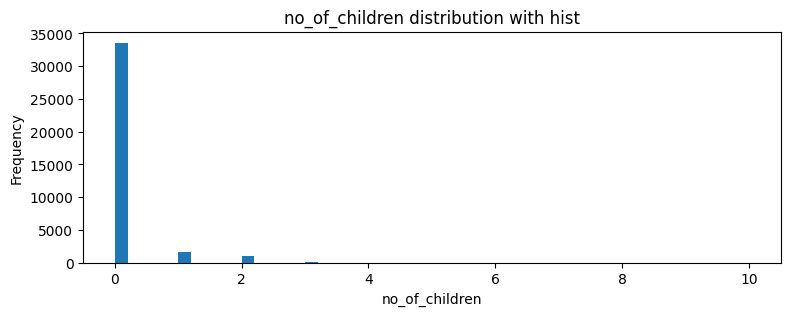

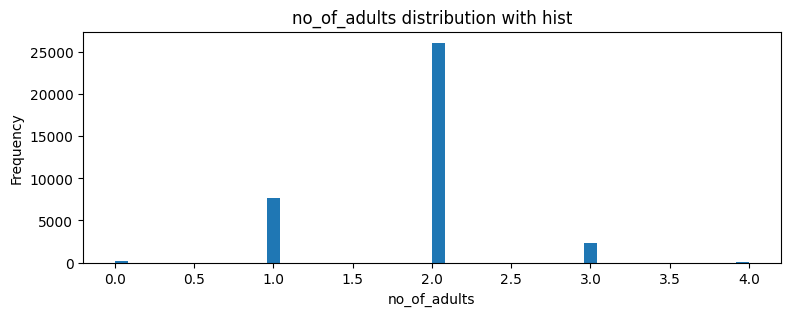

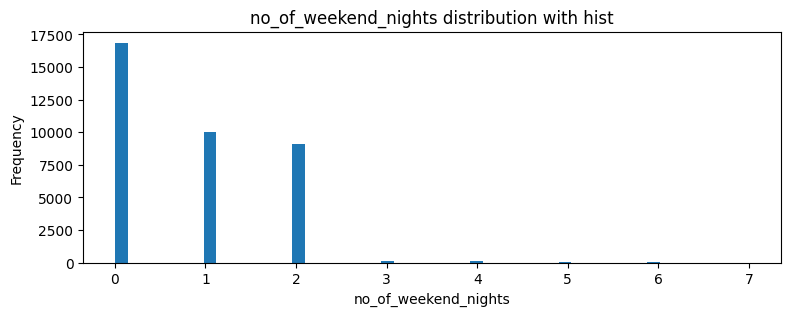

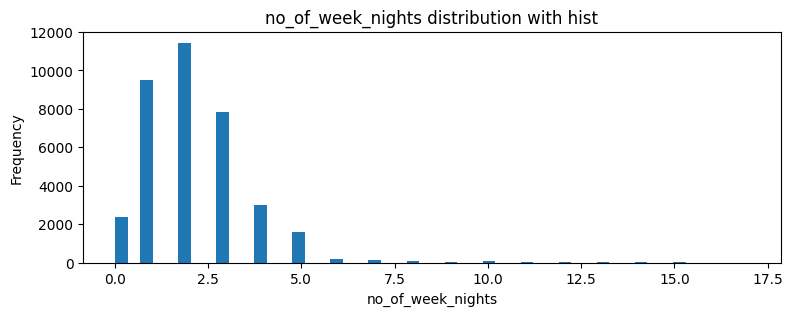

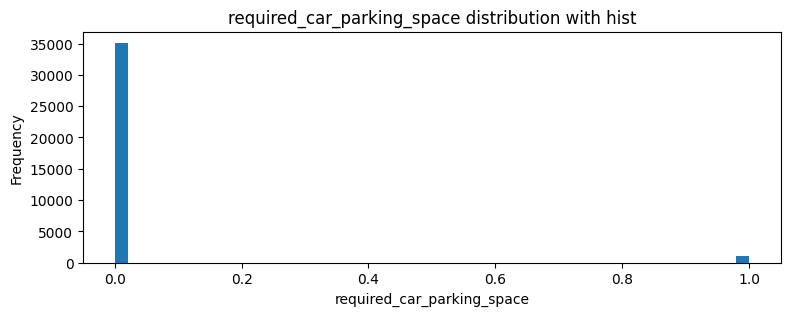

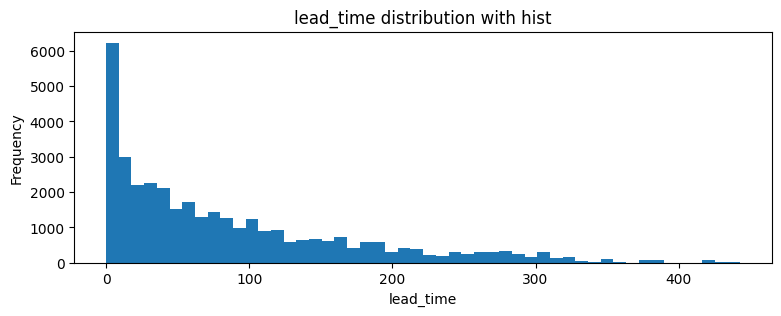

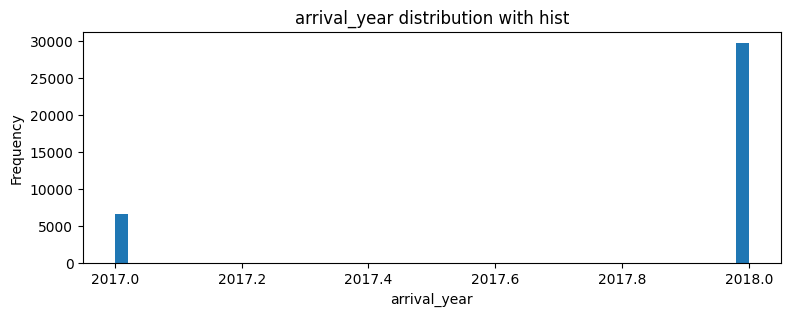

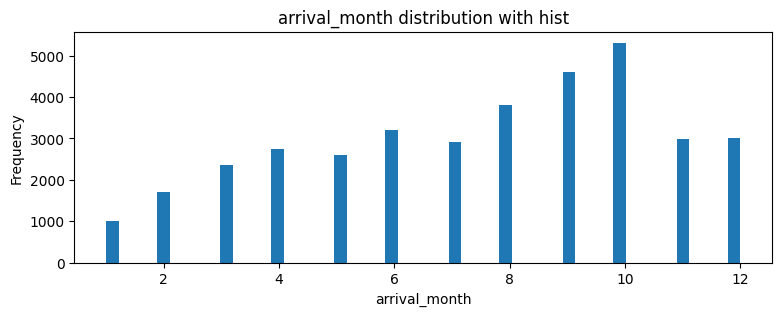

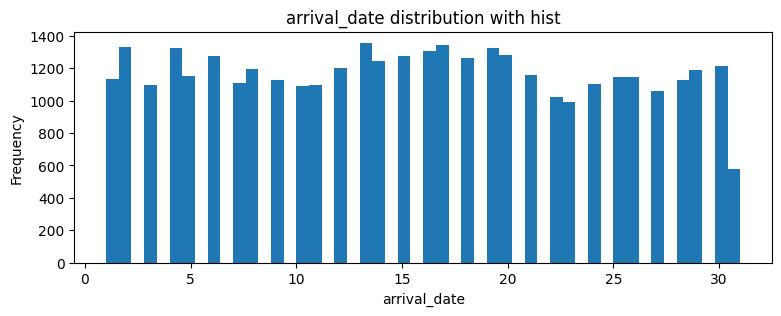

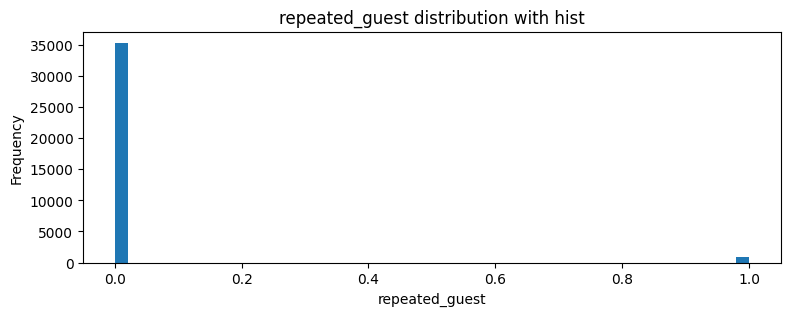

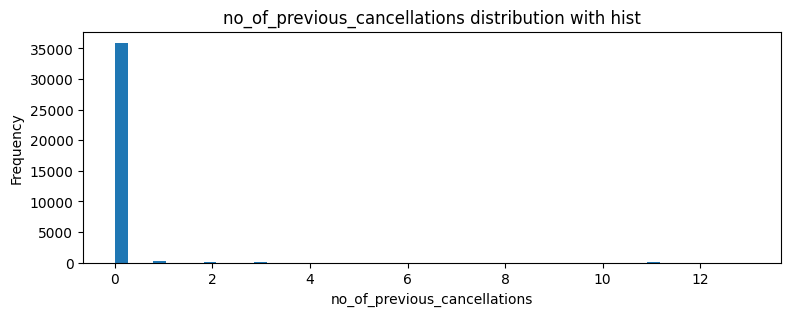

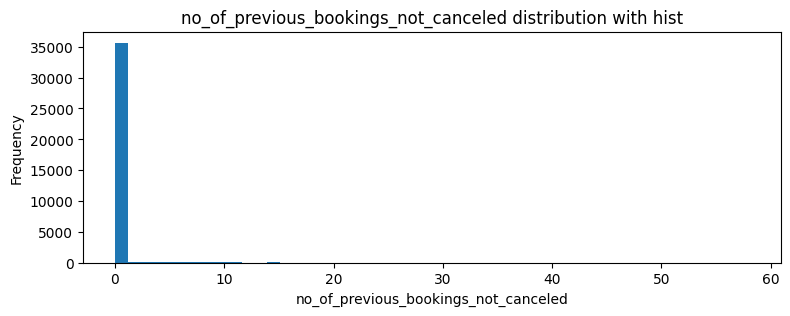

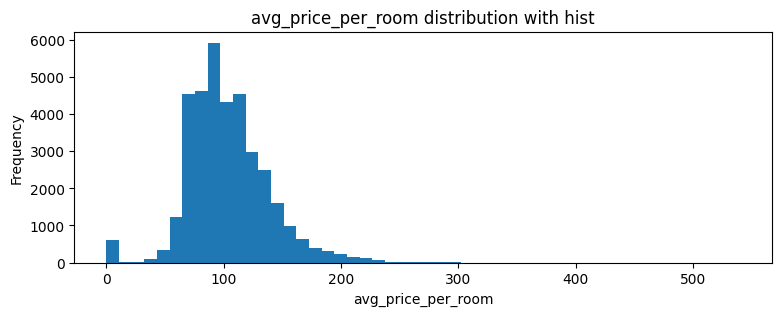

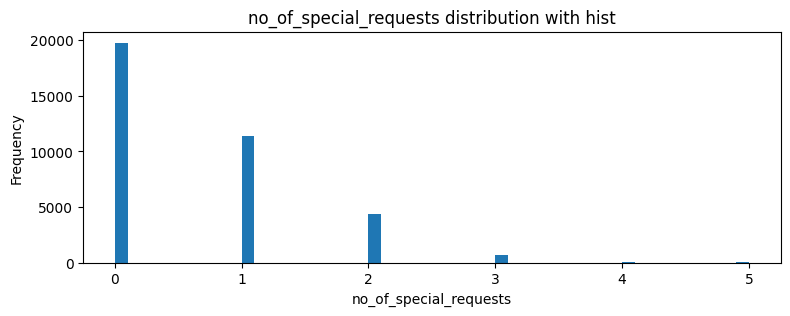

In [ ]:
numericVar = ["no_of_children","no_of_adults", "no_of_weekend_nights","no_of_week_nights",
              "required_car_parking_space","lead_time","arrival_year","arrival_month",
              "arrival_date","repeated_guest","no_of_previous_cancellations",
              "no_of_previous_bookings_not_canceled","avg_price_per_room",
              "no_of_special_requests"]

for n in numericVar:
    plot_hist(n)

- 2017, 2018년의 데이터로 구성
- required_car_parking_space는 0-1 사이에 분포
- 편향을 가진 변수가 많음

### **2-2. 범주형 변수 탐색**

In [ ]:
def bar_plot(variable):

    # get feature
    var = hotel[variable]
    # count number of categorical variable(value/sample)
    varValue = var.value_counts()

    # visualize
    plt.figure(figsize = (9,3))
    plt.bar(varValue.index, varValue)
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel("Frequency")
    plt.title(variable)
    plt.show()
    print("{}: \n {}".format(variable,varValue))

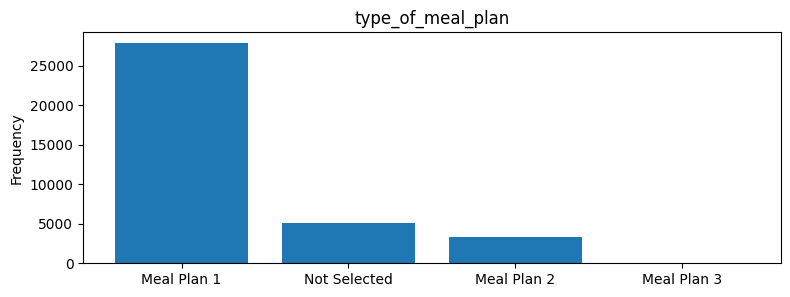

type_of_meal_plan: 
 type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64


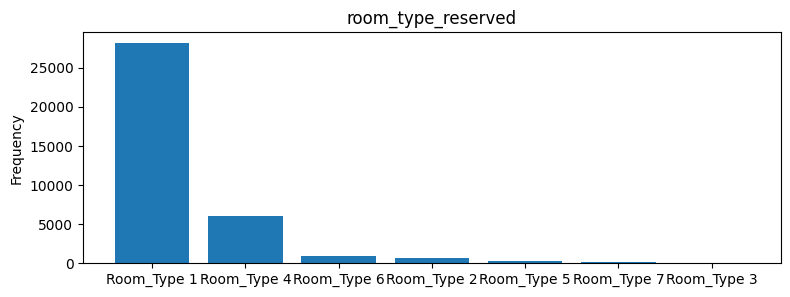

room_type_reserved: 
 room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64


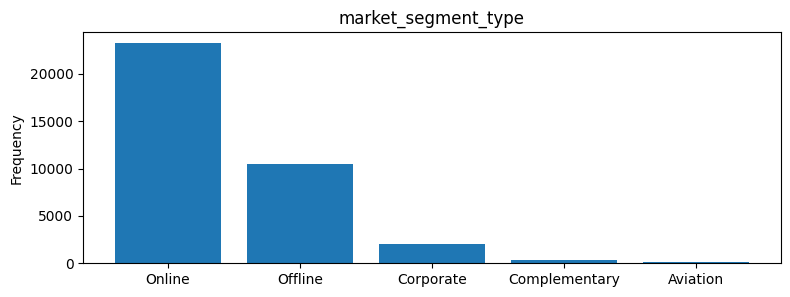

market_segment_type: 
 market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64


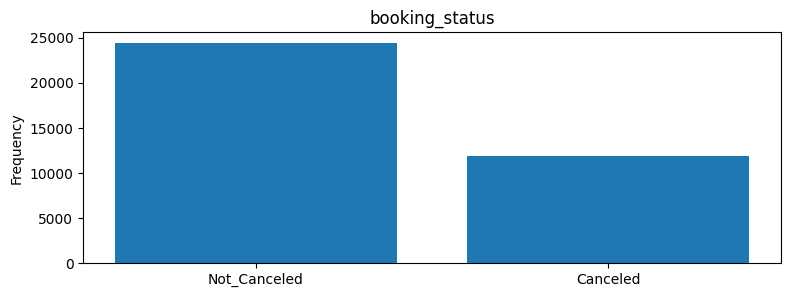

booking_status: 
 booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64


In [ ]:
categoryVar = ["type_of_meal_plan","room_type_reserved",
               "market_segment_type","booking_status"]

for c in categoryVar:
    bar_plot(c)

- meal_plan 1, Room Type 1이 선호됨

### **2-3. Data Analysis**

#### (1) 결측값

In [ ]:
hotel.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


In [ ]:
hotel.columns[hotel.isnull().any()]

Index([], dtype='object')

- 결측값이 없는 무결한 데이터

#### (2) 이상치

In [ ]:
numeric_cols = [
    'no_of_children',
    'no_of_adults',
    'no_of_weekend_nights',
    'no_of_week_nights',
    'required_car_parking_space',
    'lead_time',
    'repeated_guest',
    'no_of_previous_cancellations',
    'no_of_previous_bookings_not_canceled',
    'avg_price_per_room',
    'no_of_special_requests'
]

outlier_result = []

for col in numeric_cols:
    Q1 = hotel[col].quantile(0.25)
    Q3 = hotel[col].quantile(0.75)
    IQR = Q3 - Q1

    # 이상치 기준
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    outliers = hotel[
        (hotel[col] < lower_bound) |
        (hotel[col] > upper_bound)
    ]

    outlier_result.append({
        'variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': len(outliers),
        'outlier_ratio(%)': len(outliers) / len(hotel) * 100
    })

outlier_df = pd.DataFrame(outlier_result)

outlier_df


,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_ratio(%)
0,no_of_children,0.0,0.0,0.0,0.0,0.0,2698,7.437629
1,no_of_adults,2.0,2.0,0.0,2.0,2.0,10167,28.027567
2,no_of_weekend_nights,0.0,2.0,2.0,-6.0,8.0,0,0.000000
3,no_of_week_nights,1.0,3.0,2.0,-5.0,9.0,115,0.317023
4,required_car_parking_space,0.0,0.0,0.0,0.0,0.0,1124,3.098553
5,lead_time,17.0,126.0,109.0,-310.0,453.0,0,0.000000
6,repeated_guest,0.0,0.0,0.0,0.0,0.0,930,2.563749
7,no_of_previous_cancellations,0.0,0.0,0.0,0.0,0.0,338,0.931771
8,no_of_previous_bookings_not_canceled,0.0,0.0,0.0,0.0,0.0,812,2.238456
9,avg_price_per_room,80.3,120.0,39.7,-38.8,239.1,93,0.256375


In [ ]:
len(outlier_df)

11

In [ ]:
(outlier_df['outlier_count'] > 0).sum()

np.int64(9)

- 11개 변수 중 9개 변수에서 이상치가 발견됨

In [ ]:
outlier_df[
    outlier_df['outlier_count'] > 0
][['variable', 'outlier_count', 'outlier_ratio(%)']]

,variable,outlier_count,outlier_ratio(%)
0,no_of_children,2698,7.437629
1,no_of_adults,10167,28.027567
3,no_of_week_nights,115,0.317023
4,required_car_parking_space,1124,3.098553
6,repeated_guest,930,2.563749
7,no_of_previous_cancellations,338,0.931771
8,no_of_previous_bookings_not_canceled,812,2.238456
9,avg_price_per_room,93,0.256375
10,no_of_special_requests,8,0.022054


- 3*IQR 기준으로 이상치를 탐색한 결과 일부 변수에서 이상치가 발견됨. 그러나 해당 값들은 예약 횟수, 요청 횟수, 숙박 기간 등 실제 고객의 예약 특성을 나타내는 값일 수 있으므로 EDA 단계에서 임의로 제거하지 않는 것으로 결정


#### (3) 목표 변수(booking_status)

In [ ]:
hotel['booking_status'].value_counts()

,count
booking_status,
Not_Canceled,24390
Canceled,11885


In [ ]:
hotel['booking_status'].value_counts(normalize=True) * 100

,proportion
booking_status,
Not_Canceled,67.236389
Canceled,32.763611


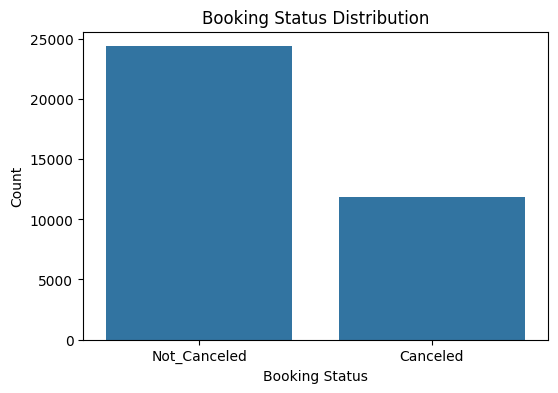

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=hotel, x='booking_status')

plt.title('Booking Status Distribution')
plt.xlabel('Booking Status')
plt.ylabel('Count')

plt.show()

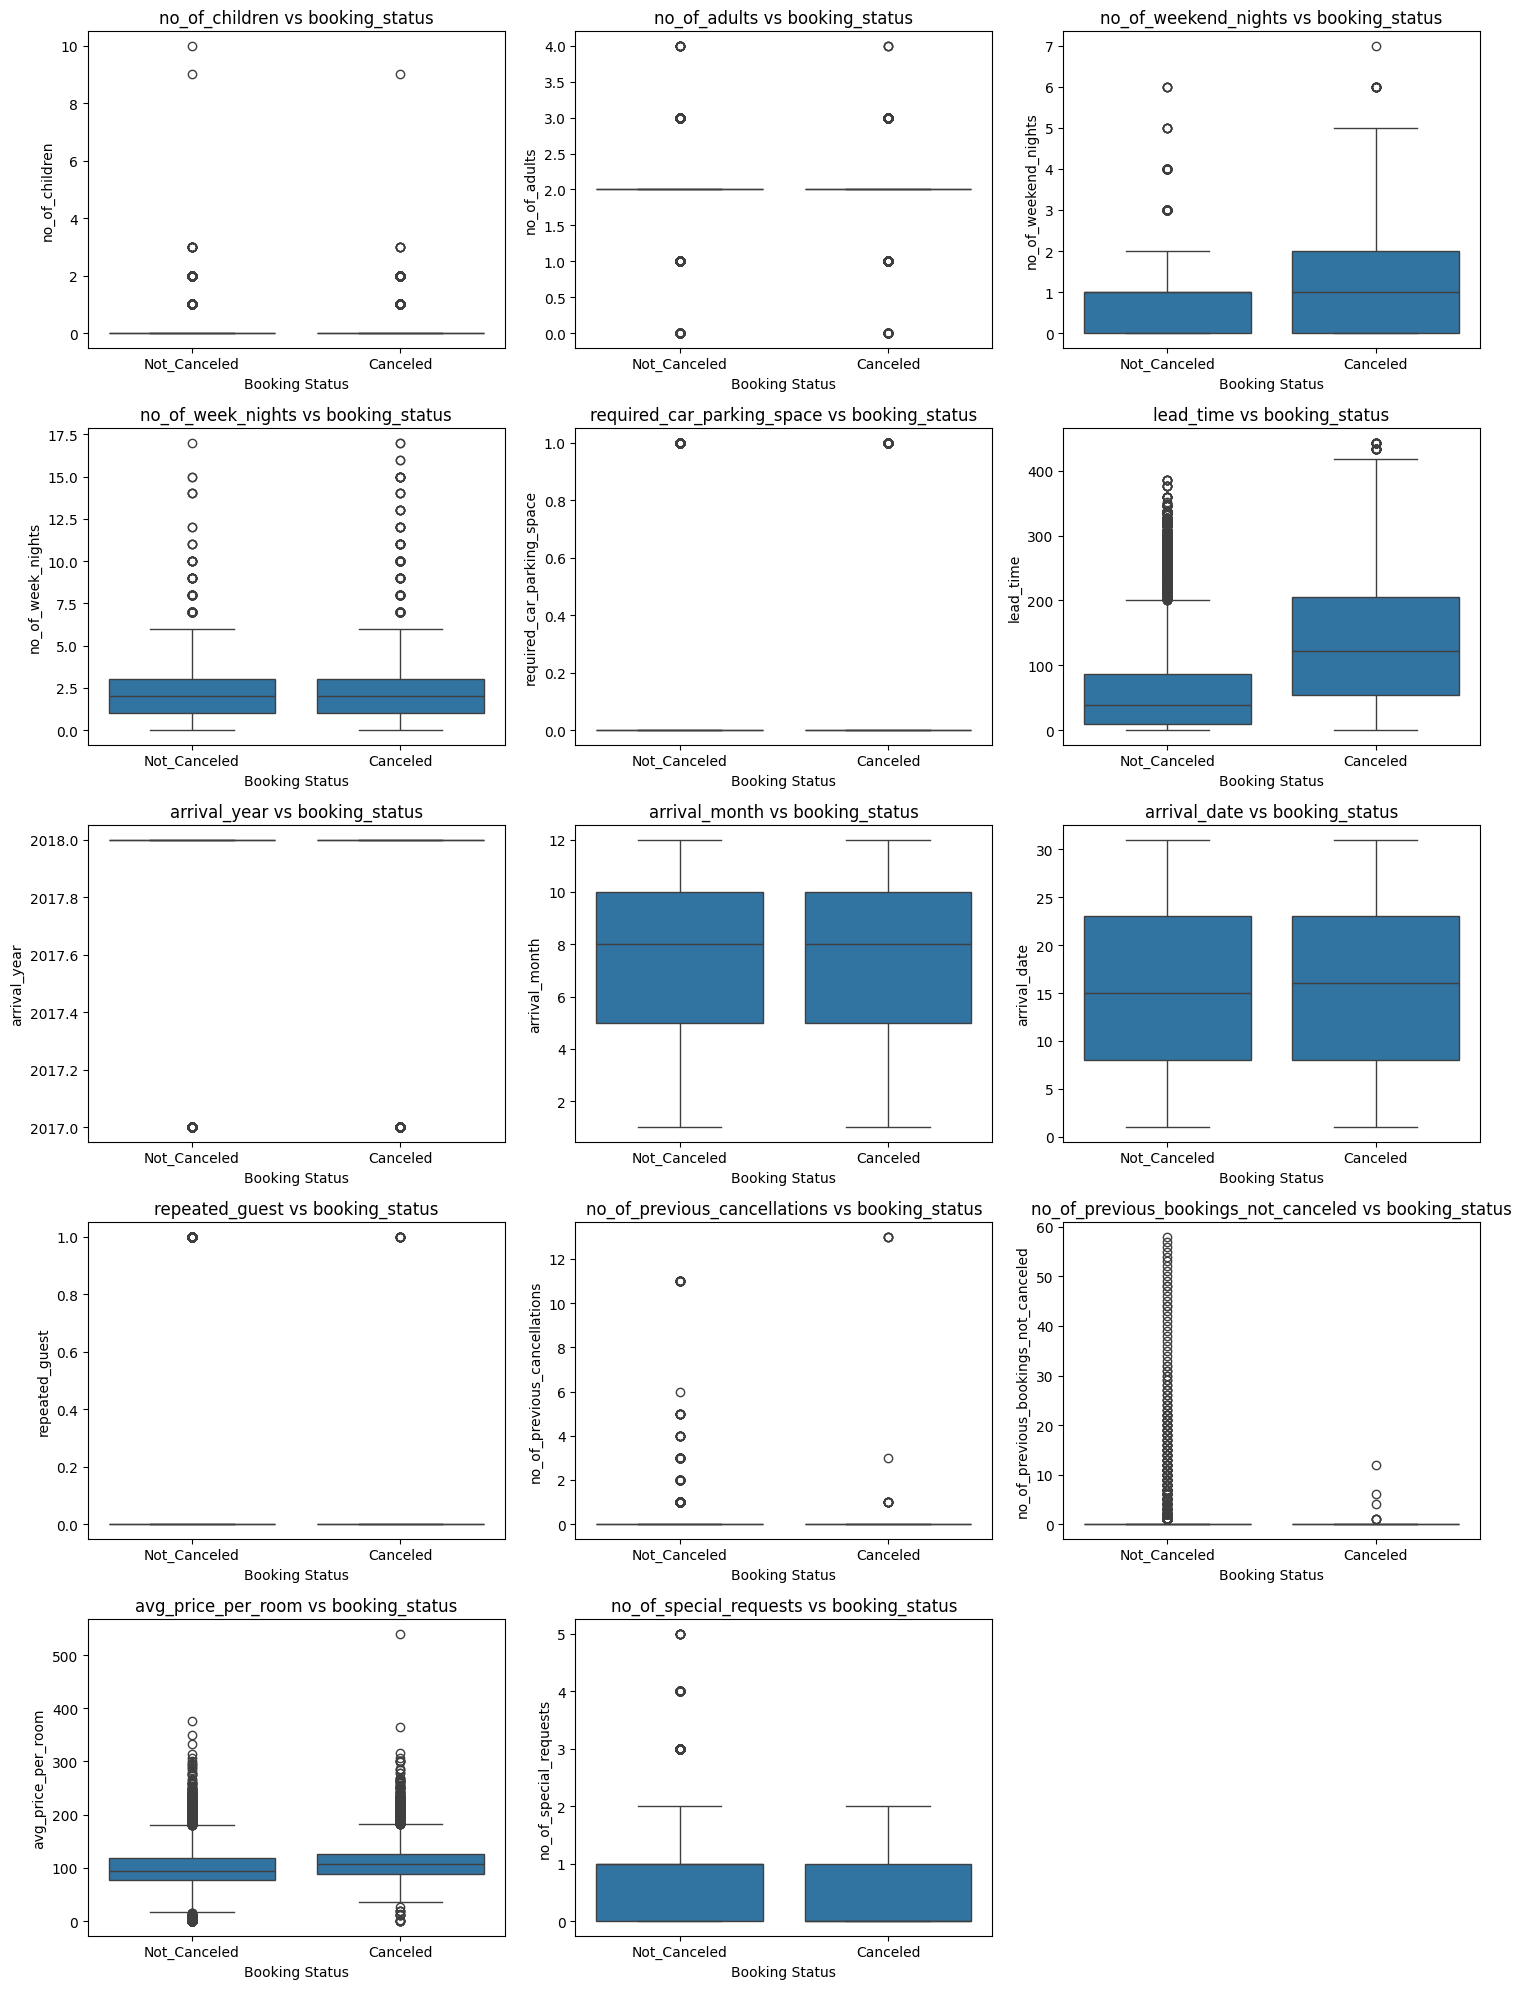

In [ ]:
# 수치형 변수와 목표변수의 관계
numeric_features = [
    'no_of_children',
    'no_of_adults',
    'no_of_weekend_nights',
    'no_of_week_nights',
    'required_car_parking_space',
    'lead_time',
    'arrival_year',
    'arrival_month',
    'arrival_date',
    'repeated_guest',
    'no_of_previous_cancellations',
    'no_of_previous_bookings_not_canceled',
    'avg_price_per_room',
    'no_of_special_requests'
]

fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(
        data=hotel,
        x='booking_status',
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs booking_status')
    axes[i].set_xlabel('Booking Status')
    axes[i].set_ylabel(col)

# 남는 그래프 칸 제거
for i in range(len(numeric_features), len(axes)):
    axes[i].remove()

plt.tight_layout()
plt.show()

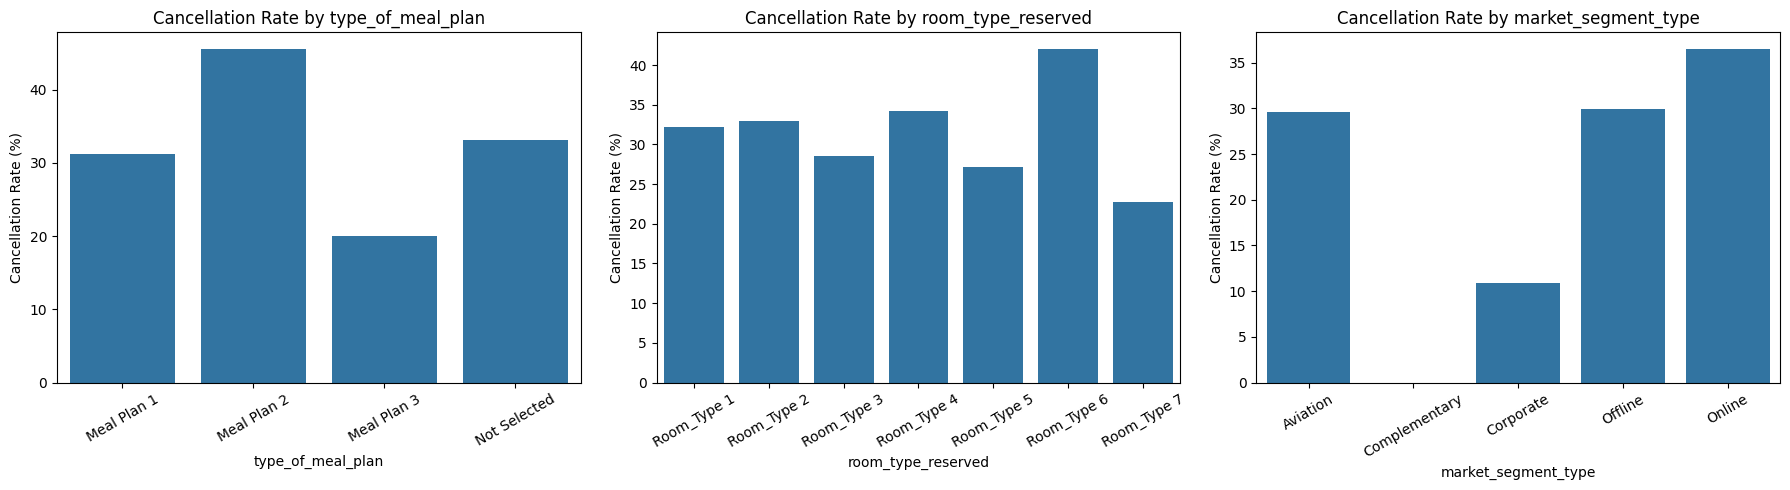

In [ ]:
# 범주형 변수와 목표변수의 관계
categorical_features = [
    'type_of_meal_plan',
    'room_type_reserved',
    'market_segment_type'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(categorical_features):

    cancel_rate = (
        hotel.groupby(col)['booking_status']
        .apply(lambda x: (x == 'Canceled').mean() * 100)
        .reset_index(name='cancel_rate')
    )

    sns.barplot(
        data=cancel_rate,
        x=col,
        y='cancel_rate',
        ax=axes[i]
    )

    axes[i].set_title(f'Cancellation Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cancellation Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### (4) 상관관계

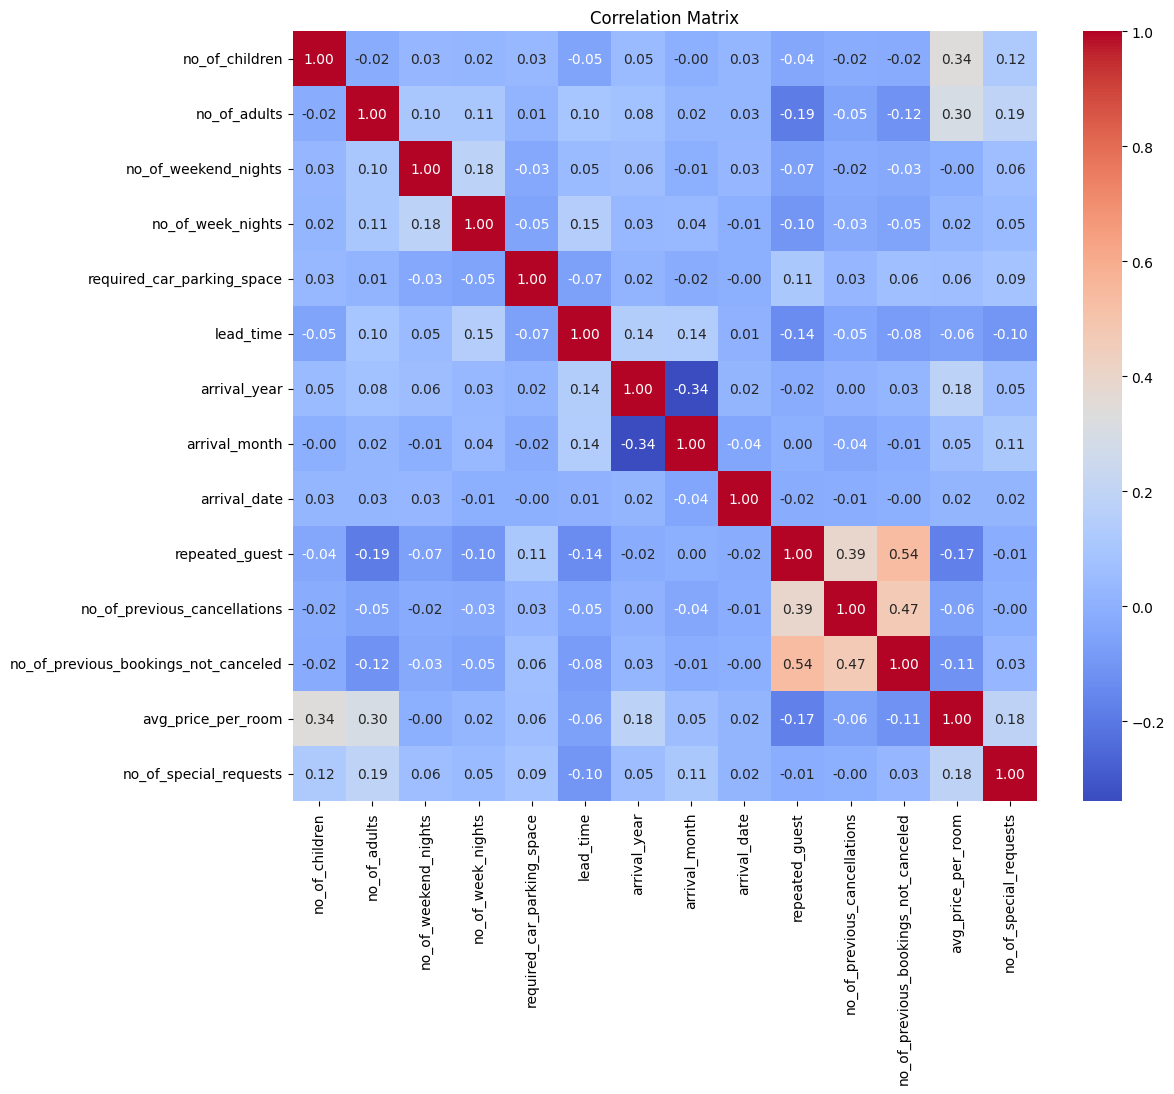

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    hotel[numericVar].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

- 매우 강한 상관관계는 파악되지 않음
- repeated_guest ↔ no_of_previous_bookings_not_canceled : 0.54
- repeated_guest ↔ no_of_previous_cancellations : 0.39
- arrival_year ↔ arrival_month : -0.34
- no_of_children ↔ avg_price_per_room : 0.34
- no_of_adults ↔ avg_price_per_room : 0.30
... 수준으로 다중공선성 때문에 변수를 제거할 필요성은 없음




---



## **3. LGBM 모델링**

- LGBM : 스케일링 필요X, 카테고리 변수 처리는 Label encoding만 진행, outlier에 강함

- 전체적인 흐름

① 데이터 준비 → ② Train/Test → ③ 클래스 불균형 → ④ RandomizedSearchCV → ⑤ 최적 파라미터 → ⑥ Validation → ⑦ LGBM 학습 → ⑧ 예측 → ⑨ 평가

In [ ]:
hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [ ]:
hotel.describe(include='all')

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
count,36275,36275.000000,36275.000000,36275.000000,36275.000000,36275,36275.000000,36275,36275.000000,36275.000000,36275.000000,36275.000000,36275,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275
unique,36275,NaN,NaN,NaN,NaN,4,NaN,7,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,2
top,INN36275,NaN,NaN,NaN,NaN,Meal Plan 1,NaN,Room_Type 1,NaN,NaN,NaN,NaN,Online,NaN,NaN,NaN,NaN,NaN,Not_Canceled
freq,1,NaN,NaN,NaN,NaN,27835,NaN,28130,NaN,NaN,NaN,NaN,23214,NaN,NaN,NaN,NaN,NaN,24390
mean,NaN,1.844962,0.105279,0.810724,2.204300,NaN,0.030986,NaN,85.232557,2017.820427,7.423653,15.596995,NaN,0.025637,0.023349,0.153411,103.423539,0.619655,NaN
std,NaN,0.518715,0.402648,0.870644,1.410905,NaN,0.173281,NaN,85.930817,0.383836,3.069894,8.740447,NaN,0.158053,0.368331,1.754171,35.089424,0.786236,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,0.000000,2017.000000,1.000000,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,2.000000,0.000000,0.000000,1.000000,NaN,0.000000,NaN,17.000000,2018.000000,5.000000,8.000000,NaN,0.000000,0.000000,0.000000,80.300000,0.000000,NaN
50%,NaN,2.000000,0.000000,1.000000,2.000000,NaN,0.000000,NaN,57.000000,2018.000000,8.000000,16.000000,NaN,0.000000,0.000000,0.000000,99.450000,0.000000,NaN
75%,NaN,2.000000,0.000000,2.000000,3.000000,NaN,0.000000,NaN,126.000000,2018.000000,10.000000,23.000000,NaN,0.000000,0.000000,0.000000,120.000000,1.000000,NaN


####(1) 데이터 준비

In [ ]:
import pandas as pd
import numpy as np

from lightgbm import LGBMClassifier, early_stopping, log_evaluation

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from scipy.stats import randint, uniform

In [ ]:
df_lgbm = hotel.copy()

# 범주형 변수 처리
df_lgbm["room_type_reserved"] = (
    df_lgbm["room_type_reserved"].astype("category")
)

df_lgbm["type_of_meal_plan"] = (
    df_lgbm["type_of_meal_plan"].astype("category")
)

df_lgbm["market_segment_type"] = (
    df_lgbm["market_segment_type"].astype("category")
)


# 날짜 정보로부터 요일 변수 생성
date = pd.to_datetime(
    df_lgbm[["arrival_year", "arrival_month", "arrival_date"]]
        .rename(columns={
            "arrival_year": "year",
            "arrival_month": "month",
            "arrival_date": "day"
        }),
    errors="coerce"
)

# 요일 생성
# 월요일=0, ..., 일요일=6
df_lgbm["arrival_weekday"] = (
    date.dt.weekday.astype("category")
)

# arrival_month도 범주형으로 변환
df_lgbm["arrival_month"] = (
    df_lgbm["arrival_month"].astype("category")
)

####(2) Train/Test 데이터 분리

In [ ]:
# 날짜 순으로 정렬
df_sorted = (
    df_lgbm
    .sort_values(
        by=["arrival_year", "arrival_month", "arrival_date"]
    )
    .reset_index(drop=True)
)

# 80 : 20 분할
split_point = int(len(df_sorted) * 0.8)

train_df = df_sorted.iloc[:split_point]
test_df = df_sorted.iloc[split_point:]


# 설명변수
X_train = train_df.drop(
    columns=["booking_status", "Booking_ID"]
)

X_test = test_df.drop(
    columns=["booking_status", "Booking_ID"]
)


# 타깃변수
# Canceled = 1
# Not_Canceled = 0
y_train = (
    train_df["booking_status"] == "Canceled"
).astype(int)

y_test = (
    test_df["booking_status"] == "Canceled"
).astype(int)


print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

X_train : (29020, 18)
y_train : (29020,)
X_test  : (7255, 18)
y_test  : (7255,)


####(3) 클래스 불균형 처리

In [ ]:
y_train.value_counts()

,count
booking_status,
0,19643
1,9377


In [ ]:
class_weight = (y_train == 0).sum() / (y_train ==1).sum()
class_weight

np.float64(2.0948064412925245)

####(4) LGBM 하이퍼파라미터 탐색
- RandomizedSearchCV


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_dist = {
    "n_estimators": randint(100, 800),
    "learning_rate": uniform(0.01, 0.15),
    "max_depth": randint(3, 12),
    "num_leaves": randint(20, 100),
    "min_child_samples": randint(10, 80),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0, 1)
}

model = LGBMClassifier(
    random_state=42,
    scale_pos_weight=class_weight,
    n_jobs=-1,
    subsample_freq=1
)

tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[LightGBM] [Info] Number of positive: 9377, number of negative: 19643
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003845 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 651
[LightGBM] [Info] Number of data points in the train set: 29020, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.323122 -> initscore=-0.739461
[LightGBM] [Info] Start training from score -0.739461
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

In [ ]:
best_hyp = random_search.best_params_

print("최적 하이퍼파라미터")
for key, value in best_hyp.items():
    print(f"{key}: {value}")

최적 하이퍼파라미터
colsample_bytree: 0.9312901539863683
learning_rate: 0.08406933945465861
max_depth: 11
min_child_samples: 24
n_estimators: 653
num_leaves: 96
reg_alpha: 0.2017192023353962
reg_lambda: 0.8957635956735194
subsample: 0.8426110669546335


####(5) Train / Validation 분리

In [ ]:
split_val = int(len(X_train) * 0.8)

X_tr = X_train.iloc[:split_val]
X_val = X_train.iloc[split_val:]

y_tr = y_train.iloc[:split_val]
y_val = y_train.iloc[split_val:]

print("X_tr :", X_tr.shape)
print("X_val:", X_val.shape)
print("y_tr :", y_tr.shape)
print("y_val:", y_val.shape)

X_tr : (23216, 18)
X_val: (5804, 18)
y_tr : (23216,)
y_val: (5804,)


####(6) 최적 하이퍼파라미터 적용 + Early Stopping

In [ ]:
####(6) 최적 하이퍼파라미터 적용 + LGBM 학습

best_hyp = random_search.best_params_

final_model = LGBMClassifier(
    **best_hyp,
    random_state=42,
    scale_pos_weight=class_weight,
    n_jobs=-1,
    subsample_freq=1
)

final_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[
        early_stopping(
            stopping_rounds=80,
            verbose=True
        ),
        log_evaluation(period=80)
    ]
)

print("Best iteration:", final_model.best_iteration_)

[LightGBM] [Info] Number of positive: 6654, number of negative: 16562
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 634
[LightGBM] [Info] Number of data points in the train set: 23216, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.286613 -> initscore=-0.911893
[LightGBM] [Info] Start training from score -0.911893
Training until validation scores don't improve for 80 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

####(7) Test 데이터 예측

In [ ]:
y_pred = final_model.predict(X_test)

####(8) 모델 평가

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# 예측 클래스
y_pred = final_model.predict(X_test)

# 예측 확률
y_prob = final_model.predict_proba(X_test)[:, 1]

# 평가 지표
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

fbeta = fbeta_score(
    y_test,
    y_pred,
    beta=0.66,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

conf = confusion_matrix(
    y_test,
    y_pred
)

print("##### LGBM #####")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F-Beta(beta=0.66): {fbeta:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf)

##### LGBM #####
Accuracy: 0.8039
Precision: 0.8449
F-Beta(beta=0.66): 0.7158
ROC-AUC: 0.8946

Confusion Matrix:
[[4503  244]
 [1179 1329]]


# **4. CatBoost 모델링**

- CatBoost: 역시 스케일링 불필요하며, 카테고리 변수 처리는 별도의 인코딩 없이 cat_features 지정만으로 처리함.

- 전체적인 흐름:
① 데이터 준비, 범주형 변수 지정, Train/Test 분할 (클래스 비율 유지) → ② CatBoost 모델 설정, 검증셋 및 조기 종료 설정 ③ CatBoost 학습/예측/평가 후 Feature Importance 시각화

####(1) 데이터 준비

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = hotel.drop(columns=['Booking_ID'])

df['booking_status'] = df['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0})

cat_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_encoded.drop(columns=['booking_status'])
y = df_encoded['booking_status']

####(2) Train/Test 데이터 분리

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (29020, 27)
X_test Shape: (7255, 27)


####(3) CatBoost 모델 설정

In [ ]:
!pip install catboost -q

from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='Logloss',
    random_seed=42,
    verbose=100
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


####(4) 학습/예측/평가

0:	learn: 0.6579239	test: 0.6573832	best: 0.6573832 (0)	total: 18.6ms	remaining: 18.6s
100:	learn: 0.3276230	test: 0.3197285	best: 0.3197285 (100)	total: 3.23s	remaining: 28.7s
200:	learn: 0.2951782	test: 0.2917300	best: 0.2917300 (200)	total: 7.13s	remaining: 28.3s
300:	learn: 0.2727828	test: 0.2746046	best: 0.2746046 (300)	total: 9.41s	remaining: 21.8s
400:	learn: 0.2577968	test: 0.2650731	best: 0.2650731 (400)	total: 10.4s	remaining: 15.5s
500:	learn: 0.2458879	test: 0.2591528	best: 0.2591528 (500)	total: 11.4s	remaining: 11.4s
600:	learn: 0.2368724	test: 0.2551948	best: 0.2551948 (600)	total: 12.4s	remaining: 8.21s
700:	learn: 0.2291032	test: 0.2522615	best: 0.2522615 (700)	total: 13.4s	remaining: 5.71s
800:	learn: 0.2221683	test: 0.2498917	best: 0.2498894 (799)	total: 14.4s	remaining: 3.58s
900:	learn: 0.2162177	test: 0.2482874	best: 0.2482618 (898)	total: 15.4s	remaining: 1.69s
999:	learn: 0.2102455	test: 0.2462646	best: 0.2462646 (999)	total: 17.1s	remaining: 0us

bestTest = 0.2

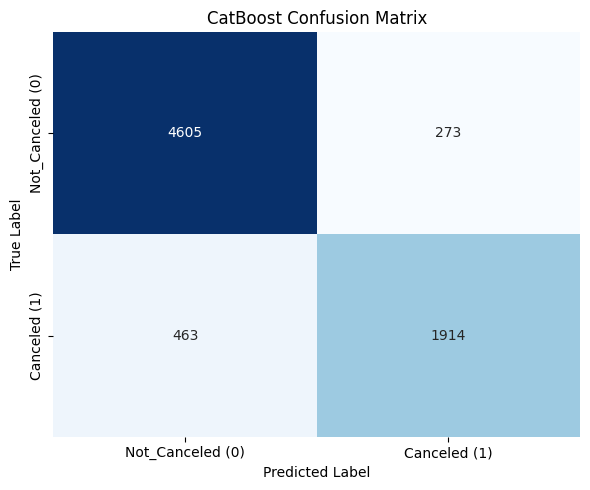

In [ ]:
cb_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
    use_best_model=True
)

y_pred_cb = cb_model.predict(X_test)
y_prob_cb = cb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(
    y_test,
    y_pred_cb
)

precision = precision_score(
    y_test,
    y_pred_cb,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_cb,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_cb,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_cb
)


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

print("\nClassification Report:\n", classification_report(y_test, y_pred_cb, target_names=['Not_Canceled (0)', 'Canceled (1)']))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_cb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not_Canceled (0)', 'Canceled (1)'],
            yticklabels=['Not_Canceled (0)', 'Canceled (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CatBoost Confusion Matrix')
plt.tight_layout()
plt.show()


# **5. CatBoost Feature Importance 시각화**

/tmp/ipykernel_1479/3535078201.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')


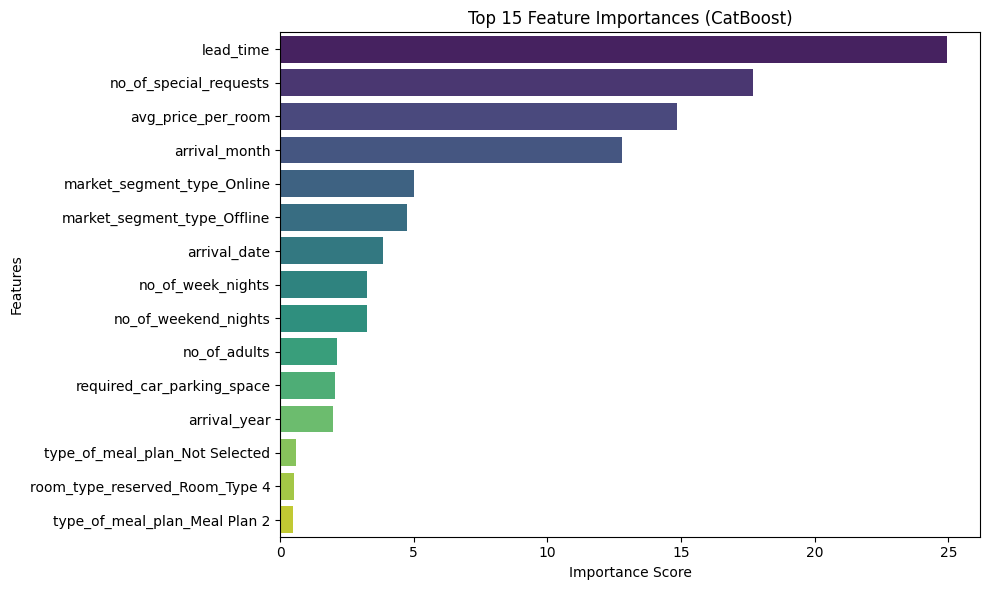

In [ ]:
feature_importances = cb_model.get_feature_importance()
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (CatBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()